In [1]:
# Packages installation
!pip3 install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


# Data Preparation


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
import pyod
from pyod.models.knn import KNN
from pyod.models.lof import LOF 
from pyod.models.iforest import IForest
from sklearn.ensemble import IsolationForest
from IPython.display import display
import warnings 
warnings.filterwarnings('ignore')

First we create a random dataset to be used in the analysis and detecting potential fraudulent activities. Apart from the customers' refunds requests, we've added columns related to viewing and examine their relationship to refunds.

In [5]:
refunds_amount = np.random.uniform(1, 500, size=10000)
refunds_nr = np.random.randint(1, 20, size=10000)
viewing_time_seconds = np.random.uniform(1, 86400, size=10000)
viewing_frequency = np.random.uniform(1, 20, size=10000)
day_of_week = np.random.randint(0, 7, size=10000)
sports_pass = np.random.randint(0, 2, size=10000)

In [6]:
df=pd.DataFrame({
    'refunds_amount': refunds_amount,
    'refunds_nr': refunds_nr,
    'viewing_time_seconds': viewing_time_seconds,
    'viewing_frequency': viewing_frequency,
    'day_of_week': day_of_week,
    'sports_pass': sports_pass
})


In [105]:
df.style.format({
    'refunds_amount': '{:.2f}',
    'viewing_time_seconds': '{:.2f}',
    'viewing_frequency': '{:.2f}'    
})

print("Dataframe shape:", df.shape, "Dataframe datatypes:", df.dtypes)


Dataframe shape: (10000, 6) Dataframe datatypes: refunds_amount          float64
refunds_nr                int64
viewing_time_seconds    float64
viewing_frequency       float64
day_of_week               int64
sports_pass               int64
dtype: object


## Feature Engineering

To define the criteria for the outliers, a set of new features was created that are:

- New features:
    - Total refunds amount: [# of refunds]*[refund amount]
    - Conditional of flagging a record as outlier based on the maximum amount refunded.
    - Conditional of flagging a record as outlier based on the maximum number of refunds.
- Encoding the Sports_pass column 

In [7]:
# Calculate total refunds amount
df['total_refunds_amount'] = df['refunds_amount'] * df['refunds_nr']

In [107]:
# Conditional of max refund amount
df['max_refund_amt'] = np.where(df['total_refunds_amount'].max()== df['total_refunds_amount'], 'Y', 'N')

In [108]:
# Conditional of max number of refunds
df['max_refunds_nr'] = np.where(df['refunds_nr'].max()== df['refunds_nr'], 'Y', 'N')

In [109]:
# Encoding the sports_pass column to a binary variable
df['sports_pass'] = df['sports_pass'].map({0: 'No', 1: 'Yes'})


# EDA

- Initial insights:
    - The distribution of the Total Refunds Amount it's on the left side of the chart, showing lower values for most of the customers' refunds.
    - The histograms of the numeric columns show an even distributions across all the values.
    - Viewing times are lower from Friday to Saturday. That isn't expected as these are the days where we'd expect to see customers viewing more content.
    - The boxplots of the Total Refunds Amount show some outliers that are higher than the upper quartile.


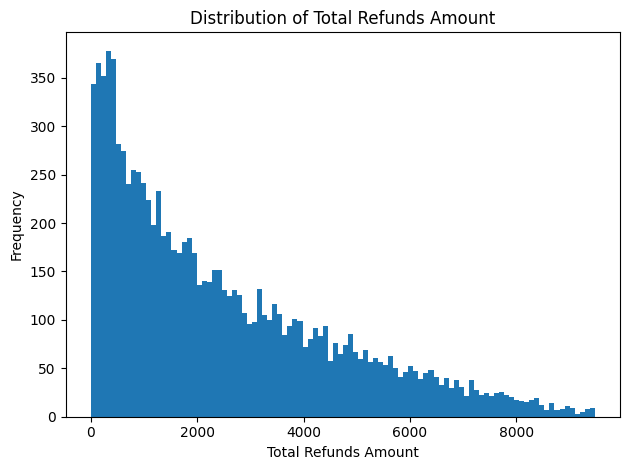

In [110]:
plt.hist(df['total_refunds_amount'], bins=100)
plt.title('Distribution of Total Refunds Amount')
plt.xlabel('Total Refunds Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

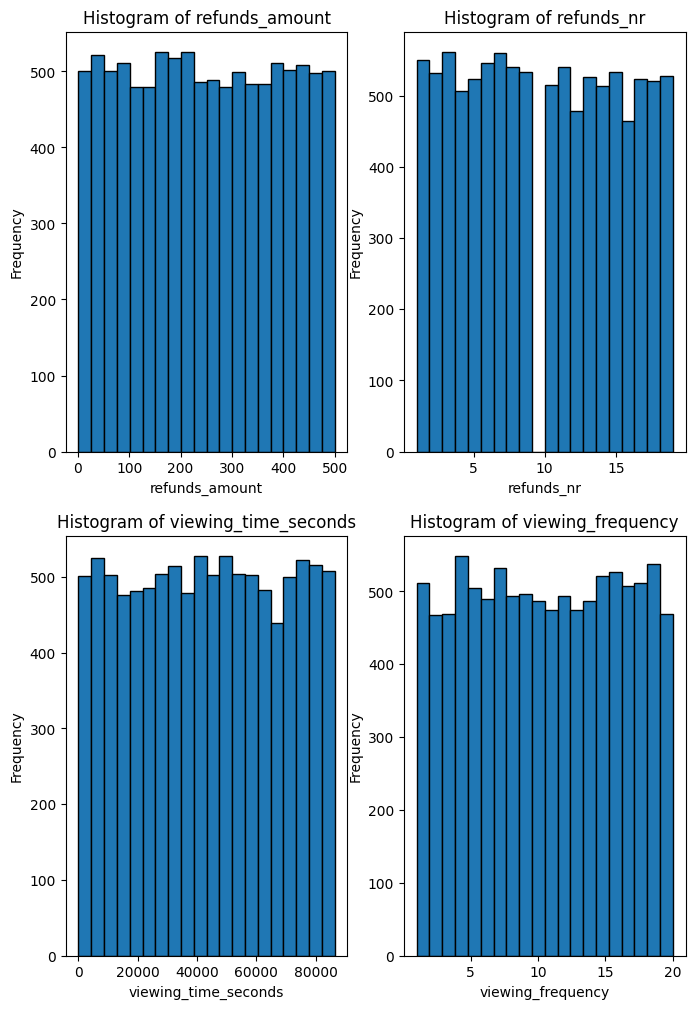

In [111]:
columns = ['refunds_amount','refunds_nr','viewing_time_seconds','viewing_frequency']

fig, ax = plt.subplots(2, 2, figsize=(8, 12))

for column in enumerate(columns):
    row = column[0] // 2
    col = column[0] % 2
    ax[row, col].hist(df[column[1]], bins=20, edgecolor='black')
    ax[row, col].set_title(f'Histogram of {column[1]}')
    ax[row, col].set_xlabel(column[1])
    ax[row, col].set_ylabel('Frequency')


<Axes: ylabel='day_of_week'>

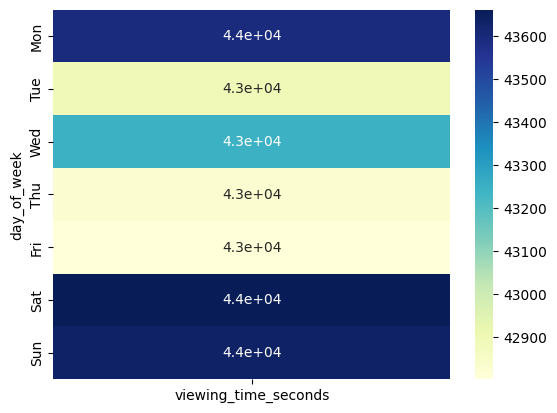

In [112]:
# Transforming the days of the week and adding a histogram to see the viewing time frequency by day and the total refunds amount
df['day_of_week']=pd.Categorical(df['day_of_week'], categories=[0,1,2,3,4,5,6], 
                                 ordered=True).rename_categories(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
sns.heatmap(df.pivot_table(index='day_of_week',values='viewing_time_seconds', aggfunc='mean'), annot=True, cmap='YlGnBu')

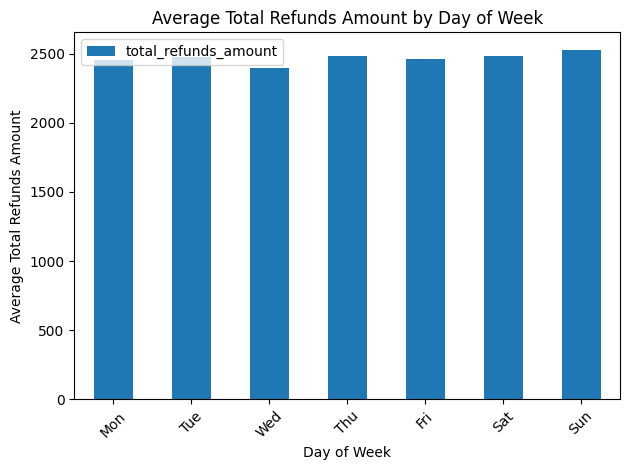

In [113]:
df.pivot_table(index='day_of_week', values='total_refunds_amount', aggfunc='mean').plot(kind='bar')
plt.title('Average Total Refunds Amount by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Total Refunds Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

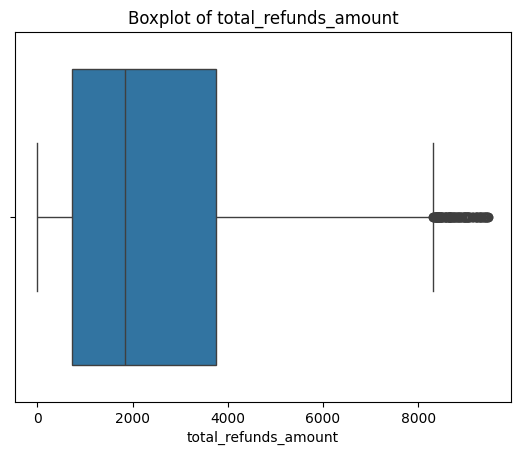

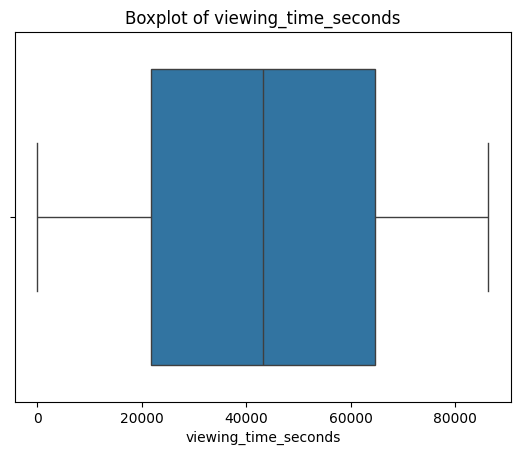

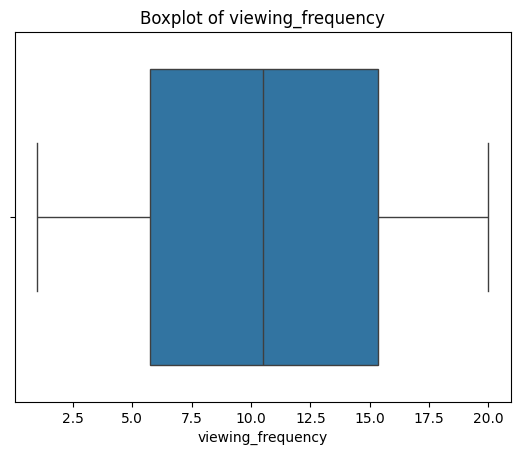

In [114]:
columns = ['total_refunds_amount','viewing_time_seconds','viewing_frequency']
 #   plt.figure(figsize=(6, 4))

for i in columns:
    sns.boxplot(x=df[i])
    plt.title(f'Boxplot of {i}')
    plt.show()

# Methods for Identifying Outliers

## Z-score
The first test we'll do is looking at the z-score, and the python stats package can provide this score without doing any calculations. As a rule of thumb the z-score<-3 | z-score>3 is an indication of an outlier. 

In our case we can only have positive total refunds amount (as our primary metric for detecting outliers), so we'll check for z-score>3.


In [115]:
def mark_outliers_iqr_zscore(df, col, iqr_multiplier=1.5, z_thresh=3):
    """
    Paramaters
    df (pd.DataFrame): The input DataFrame.
    col (str): The column name for which to detect outliers.
    iqr_multiplier (float): The multiplier for the IQR method.
    z_thresh (float): The threshold for the z-score method.

    Returns
    pd.DataFrame: The modified DataFrame with outlier columns added.
    """
    df = df.copy()
    df['25pc_tr'] = df[col].quantile(0.25)
    df['50pc_tr'] = df[col].quantile(0.50)
    df['75pc_tr'] = df[col].quantile(0.75)
    df['IQR_tr'] = df['75pc_tr'] - df['25pc_tr']
    df['lower_bound_tr'] = df['25pc_tr'] - iqr_multiplier * df['IQR_tr']
    df['upper_bound_tr'] = df['75pc_tr'] + iqr_multiplier * df['IQR_tr']
    df['z_score_outlier_flag'] = np.where((df[col] < df['lower_bound_tr']) | (df[col] > df['upper_bound_tr']), 'Outlier', 'Inlier')
    df['z_score'] = np.abs(stats.zscore(df[col]))
    df['z_score_outlier_score'] = np.where(df['z_score'] > z_thresh, np.abs(df[col]), 0)
    return df

In [118]:
# Filtering the records on z-score>3

df = mark_outliers_iqr_zscore(df, 'total_refunds_amount')
df[df['z_score_outlier_score']>=3]
df.select_dtypes(['float','integer']).round(2)

,refunds_amount,refunds_nr,viewing_time_seconds,viewing_frequency,total_refunds_amount,25pc_tr,50pc_tr,75pc_tr,IQR_tr,lower_bound_tr,upper_bound_tr,z_score,z_score_outlier_score
0,467.36,5,73703.71,2.61,2336.81,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,0.06,0.0
1,427.40,8,14066.65,12.62,3419.21,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,0.45,0.0
2,22.93,2,26533.83,17.32,45.86,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,1.14,0.0
3,82.77,2,4284.73,11.14,165.54,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,1.08,0.0
4,65.04,7,17873.72,5.48,455.30,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,0.95,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,366.02,13,8107.86,11.56,4758.30,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,1.08,0.0
9996,321.69,2,85552.50,7.22,643.38,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,0.86,0.0
9997,456.73,1,74793.77,13.10,456.73,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,0.95,0.0
9998,23.41,13,73358.50,16.21,304.35,718.56,1849.6,3757.52,3038.96,-3839.88,8315.97,1.02,0.0


## Isolation Forest and KNN methods

In [120]:
from pyod.models.iforest import IForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [129]:
df[df.select_dtypes(include=['float', 'int']).columns] = (
    df.select_dtypes(include=['float', 'int']).round(2)
)


## Isolation Forest


In [130]:
def isolation_forest_outliers(df,var)->pd.DataFrame:
    """
    Arguments:
    df : pandas DataFrame
    var : str, column name in df to detect outliers on 
    Detect outliers in a DataFrame using the Isolation Forest algorithm.
    Contamination is set to 1% by default, as default score.
    """

    df_if=df[[var]]
    clf=IsolationForest(n_estimators=100, max_samples='auto', contamination=.01, max_features=1.0)
    clf.fit(df_if)
    df['anomaly_score']=clf.predict(df_if)
    df['score']=clf.decision_function(df_if)
    df['if_outlier_inlier']=np.where((df['anomaly_score']==-1),'Outlier','Inlier')
    return df

In [131]:
isolation_forest_outliers(df,'total_refunds_amount')

,refunds_amount,refunds_nr,viewing_time_seconds,viewing_frequency,day_of_week,sports_pass,total_refunds_amount,max_refund_amt,max_refunds_nr,25pc_tr,...,75pc_tr,IQR_tr,lower_bound_tr,upper_bound_tr,z_score_outlier_flag,z_score,z_score_outlier_score,anomaly_score,score,if_outlier_inlier
0,467.36,5,73703.71,2.61,Thu,No,2336.81,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,0.06,0.0,1,0.199190,Inlier
1,427.40,8,14066.65,12.62,Sun,No,3419.21,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,0.45,0.0,1,0.192939,Inlier
2,22.93,2,26533.83,17.32,Fri,No,45.86,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,1.14,0.0,1,0.113575,Inlier
3,82.77,2,4284.73,11.14,Mon,Yes,165.54,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,1.08,0.0,1,0.183778,Inlier
4,65.04,7,17873.72,5.48,Wed,Yes,455.30,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,0.95,0.0,1,0.211546,Inlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,366.02,13,8107.86,11.56,Wed,No,4758.30,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,1.08,0.0,1,0.147032,Inlier
9996,321.69,2,85552.50,7.22,Fri,No,643.38,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,0.86,0.0,1,0.192855,Inlier
9997,456.73,1,74793.77,13.10,Thu,Yes,456.73,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,0.95,0.0,1,0.211546,Inlier
9998,23.41,13,73358.50,16.21,Thu,Yes,304.35,N,N,718.56,...,3757.52,3038.96,-3839.88,8315.97,Inlier,1.02,0.0,1,0.187533,Inlier


In [133]:
def knn_outliers(df,var):
    """
    Arguments:
    df : pandas DataFrame
    var : str, column name in df to detect outliers on 
    Detect outliers in a DataFrame using the Isolation Forest algorithm.
    Contamination is set to 1% by default, as default score.
    """

    df_knn=df[[var]]
    clf=KNN(contamination=.01)
    clf.fit(df_knn)
    df['anomaly_score']=clf.predict(df_knn)
    df['score']=clf.decision_function(df_knn)
    df['knn_outlier_inlier']=np.where((df['anomaly_score']==1),'Outlier','Inlier')
    return df

In [134]:
knn_outliers(df,'total_refunds_amount')

,refunds_amount,refunds_nr,viewing_time_seconds,viewing_frequency,day_of_week,sports_pass,total_refunds_amount,max_refund_amt,max_refunds_nr,25pc_tr,...,IQR_tr,lower_bound_tr,upper_bound_tr,z_score_outlier_flag,z_score,z_score_outlier_score,anomaly_score,score,if_outlier_inlier,knn_outlier_inlier
0,467.36,5,73703.71,2.61,Thu,No,2336.81,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,0.06,0.0,0,0.87,Inlier,Inlier
1,427.40,8,14066.65,12.62,Sun,No,3419.21,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,0.45,0.0,0,1.43,Inlier,Inlier
2,22.93,2,26533.83,17.32,Fri,No,45.86,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,1.14,0.0,0,0.75,Inlier,Inlier
3,82.77,2,4284.73,11.14,Mon,Yes,165.54,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,1.08,0.0,0,0.29,Inlier,Inlier
4,65.04,7,17873.72,5.48,Wed,Yes,455.30,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,0.95,0.0,0,0.62,Inlier,Inlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,366.02,13,8107.86,11.56,Wed,No,4758.30,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,1.08,0.0,0,4.25,Inlier,Inlier
9996,321.69,2,85552.50,7.22,Fri,No,643.38,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,0.86,0.0,0,0.30,Inlier,Inlier
9997,456.73,1,74793.77,13.10,Thu,Yes,456.73,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,0.95,0.0,0,0.32,Inlier,Inlier
9998,23.41,13,73358.50,16.21,Thu,Yes,304.35,N,N,718.56,...,3038.96,-3839.88,8315.97,Inlier,1.02,0.0,0,0.83,Inlier,Inlier


# Outlier Analysis

In [136]:
print('The number of outliers detected by using all the methods is:', df.loc[(df['knn_outlier_inlier'].astype(str)=='Outlier') | (df['if_outlier_inlier'].astype(str)=='Outlier') | (df['z_score_outlier_flag'].astype(str)=='Outlier'), :].shape[0])

The number of outliers detected by using all the methods is: 129


In [ ]:
df[df['z_score_outlier_flag'].astype(str)=='Outlier']

,refunds_amount,refunds_nr,viewing_time_seconds,viewing_frequency,day_of_week,sports_pass,total_refunds_amount,max_refund_amt,max_refunds_nr,25pc_tr,...,IQR_tr,lower_bound_tr,upper_bound_tr,z_score_outlier_flag,z_score,z_score_outlier_score,anomaly_score,score,if_outlier_inlier,knn_outlier_inlier
240,467.346139,18,18355.095252,19.902076,Wed,Yes,8412.230496,N,N,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.755137,0.000000,0,6.346767,Outlier,Inlier
354,486.015175,19,43498.094611,17.371414,Tue,No,9234.288324,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,3.138430,9234.288324,1,52.643092,Outlier,Outlier
359,469.500407,19,43861.766354,16.770560,Fri,No,8920.507731,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.992127,0.000000,0,13.147852,Outlier,Inlier
452,495.584857,18,34335.226565,2.431865,Fri,No,8920.527431,N,N,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.992136,0.000000,0,13.128152,Outlier,Inlier
502,456.174525,19,28880.783044,5.145717,Thu,Yes,8667.315980,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.874073,0.000000,0,14.844029,Outlier,Inlier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9474,477.376986,18,31708.114321,2.423529,Wed,Yes,8592.785753,N,N,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.839323,0.000000,1,20.012327,Outlier,Outlier
9607,472.425744,19,19414.048189,17.489053,Thu,No,8976.089129,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,3.018042,8976.089129,1,17.984879,Outlier,Outlier
9615,443.559947,19,36773.463663,3.636832,Fri,No,8427.638998,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.762321,0.000000,0,4.514585,Outlier,Inlier
9645,443.538747,19,20564.617786,14.083655,Mon,Yes,8427.236201,N,Y,747.369707,...,3057.923978,-3839.516261,8392.179653,Outlier,2.762134,0.000000,0,4.111787,Outlier,Inlier


## Insights - Day of the week
In the initial analysis we had noticed that the total viewing time was lower in the days from Friday to Sunday. In this case we'll focus on the outliers seen on the days of the week, firstly, by checking if a data point is identified as an outlier with both methods, i.e. Isolation Forest and KNN. 

Based on the heatmap, the viewing per day of the week doesn't allow any safe conclusions as each group of inliers and outliers by method differs from each other. Moreover, there is no clear difference of higher viewing when both methods show outliers (both_Outlier group) and all other groups that include both inliers and outliers of data points.

In [137]:
df['Inlier_outlier_group'] = np.where(
    (df['knn_outlier_inlier'].astype(str) == 'Outlier') &
    (df['if_outlier_inlier'].astype(str) == 'Outlier'),
    'both_Outlier',
    np.where(
        (df['knn_outlier_inlier'].astype(str) == 'Inlier') &
        (df['if_outlier_inlier'].astype(str) == 'Outlier'),
        'knn_inlier_if_Outlier',
        np.where(
            (df['knn_outlier_inlier'].astype(str) == 'Outlier') &
            (df['if_outlier_inlier'].astype(str) == 'Inlier'),
            'knn_Outlier_if_inlier',
            'both_Inlier'
        )
    )
)

In [138]:
df.pivot_table(index='Inlier_outlier_group', columns='day_of_week', values='viewing_time_seconds', aggfunc='mean').round(2).style.format("{:,.2f}"). \
    background_gradient(cmap="Blues")


day_of_week,Mon,Tue,Wed,Thu,Fri,Sat,Sun
Inlier_outlier_group,,,,,,,
both_Inlier,"43,748.25","42,847.79","43,266.91","42,857.00","42,736.53","43,617.28","43,568.10"
both_Outlier,"32,136.06","46,096.12","34,079.91","31,337.27","52,867.63","46,192.18","46,730.04"
knn_Outlier_if_inlier,nan,"50,100.06",nan,"34,312.49","46,895.62","31,053.56","45,595.88"
knn_inlier_if_Outlier,"30,422.29","41,474.07","44,722.15","55,780.54","43,831.08","52,621.87","52,277.38"


# Insights


The z-score doesn't give us very good scores on measuring the outliers, so we'll focus on the Isolation Forest and KNN.

## Outliers only analysis (Isolation Forest and KNN)
The next part of the analysis focuses on comparing the outlier groups to the other groups with or without one group having any indication for outliers.

In [139]:
def compare_groups(df, group_col, value_col):
    """
    Compare the mean of a value column across different groups in a DataFrame.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    group_col (str): The name of the column to group by.
    value_col (str): The name of the value column to compare.

    Returns:
    pd.DataFrame: A pivot table showing the mean of the value column for each group.
    """

    return df.groupby(group_col)[value_col].agg(['mean', 'std','median'])
    
    
   

In [140]:
i = ['viewing_frequency', 'viewing_time_seconds', 'total_refunds_amount']

for col in i:
    display(f"Metric: {col.replace('_', ' ').title()}")
    
    styled = (
        compare_groups(df, 'Inlier_outlier_group', col)
        .style
        .format("{:,.2f}")
        .background_gradient(cmap="Blues")
    )
    
    display(styled)


'Metric: Viewing Frequency'

,mean,std,median
Inlier_outlier_group,,,
both_Inlier,10.52,5.49,10.48
both_Outlier,10.84,5.67,11.87
knn_Outlier_if_inlier,8.53,5.51,7.78
knn_inlier_if_Outlier,12.63,5.39,13.30


'Metric: Viewing Time Seconds'

,mean,std,median
Inlier_outlier_group,,,
both_Inlier,"43,236.80","24,958.33","43,197.81"
both_Outlier,"41,868.96","26,142.64","44,293.39"
knn_Outlier_if_inlier,"43,705.74","19,931.30","44,362.26"
knn_inlier_if_Outlier,"45,520.88","28,993.33","50,280.93"


'Metric: Total Refunds Amount'

,mean,std,median
Inlier_outlier_group,,,
both_Inlier,"2,395.90","2,028.25","1,821.92"
both_Outlier,"8,997.41",311.17,"9,018.08"
knn_Outlier_if_inlier,"7,978.14",261.17,"8,054.70"
knn_inlier_if_Outlier,"8,693.83",249.55,"8,653.59"


In [141]:
df[['viewing_frequency','viewing_time_seconds','total_refunds_amount']].corr().style.background_gradient(cmap='coolwarm')

,viewing_frequency,viewing_time_seconds,total_refunds_amount
viewing_frequency,1.000000,-0.008478,0.007044
viewing_time_seconds,-0.008478,1.000000,0.016161
total_refunds_amount,0.007044,0.016161,1.000000


### Outlier group analysis and metrics correlation
We kept the common outliers on both KNN and Isolation Forest methods to do a few diagnostics on some main measures to understand better their dispersion. However,  for all metrics of outliers' detection, we didn't find a significant difference between the mean and the median, and the standard deviation value isn't very far by the other metrics.

Finally, the correlation between the metrics is very low for [viewing_frequency and total_refunds_amount], and quiet low for [viewing_time_seconds and total_refunds_amount].

In [143]:
df_viewing=df.loc[(df['knn_outlier_inlier'].astype(str)=='Outlier') & (df['if_outlier_inlier'].astype(str)=='Outlier'), 
       ['viewing_frequency','viewing_time_seconds','total_refunds_amount']]

In [144]:
def gettots(x):
    """
    Calculate total statistics for a given pandas Series.
    
    Parameters:
    x (pd.Series): Input series for which to calculate statistics.
    
    Returns:
    pd.Series: A series containing the calculated statistics.
    """

    out= {}
    out['min']=x.min()
    out['max']=x.max()
    out['mean']=x.mean()
    out['median']=x.median()
    out['std']=x.std()
    return pd.Series(out)

In [145]:
df_viewing.apply(gettots).style.format("{:,.2f}")

,viewing_frequency,viewing_time_seconds,total_refunds_amount
min,1.02,258.35,"8,474.08"
max,19.99,"86,184.71","9,474.15"
mean,10.84,"41,868.96","8,997.41"
median,11.87,"44,293.39","9,018.08"
std,5.67,"26,142.64",311.17


In [146]:
df_viewing.corr()

,viewing_frequency,viewing_time_seconds,total_refunds_amount
viewing_frequency,1.000000,-0.009351,0.047847
viewing_time_seconds,-0.009351,1.000000,-0.097984
total_refunds_amount,0.047847,-0.097984,1.000000


# Sports Analysis

In [ ]:
df.groupby(['Inlier_outlier_group','sports_pass']).agg({'viewing_frequency':['mean', 'median', 'std', 'min', 'max'],
                                                        'viewing_time_seconds':['mean', 'median', 'std', 'min', 'max']}).round(2)

viewing_frequency                                   \
                                   mean        median          std         
sports_pass                          No    Yes     No    Yes    No   Yes   
Inlier_outlier_group                                                       
both_Inlier                       10.57  10.45  10.57  10.36  5.43  5.39   
both_Outlier                       8.92  10.41   8.46  10.00  5.44  4.44   
knn_Outlier_if_inlier             12.30  12.15  11.68  12.95  2.77  5.24   
knn_inlier_if_Outlier             10.14  10.56  11.00  11.44  5.64  5.39   

                                                viewing_time_seconds  \
                        min          max                        mean   
sports_pass              No   Yes     No    Yes                   No   
Inlier_outlier_group                                                   
both_Inlier            1.01  1.00  19.99  20.00             43244.32   
both_Outlier           1.16  2.66  19.74  19.69             51198.63   
knn_Outlier_if_inlier  9.11  3.73  18.77  19.22             46662.77   
knn_inlier_if_Outlier  1.48  2.83  18.12  19.14             35369.74   

                                                                         \
                                   median                 std             
sports_pass                 Yes        No       Yes        No       Yes   
Inlier_outlier_group                                                      
both_Inlier            43291.00  43426.41  43596.20  24824.16  24916.03   
both_Outlier           40220.21  46551.17  44266.40  21413.05  21289.89   
knn_Outlier_if_inlier  40027.81  45202.32  27364.22  23937.74  27683.39   
knn_inlier_if_Outlier  37614.10  32872.65  35474.73  23128.66  25033.11   

                                                              
                            min                max            
sports_pass                  No      Yes        No       Yes  
Inlier_outlier_group                                          
both_Inlier                4.44    16.40  86395.02  86396.04  
both_Outlier           12924.20  2240.20  85115.33  74561.35  
knn_Outlier_if_inlier   3923.97   870.41  85958.34  76533.63  
knn_inlier_if_Outlier    211.70   772.95  79649.77  84147.44

In [ ]:
display("### Viewing Metrics by Group & Sports Pass")

styled = (
    out.style
       .format("{:,.2f}")
       .background_gradient(cmap="Blues")
)
display(styled)


The key points from the summary table:
- Outliers group:
    - The [No Sports Pass] has a lower average viewing frequency, but higher viewing time compared to the other groups.
    - Comparing [Sports_Pass] and [Non_Sports_Pass] for the refunds amount, the groups with at least one outlier detection method (any of Isolation Forest and/ or KNN) is - as expected - higher to the inlier groups

In [ ]:
display(df.pivot_table(index='Inlier_outlier_group', columns='sports_pass', values='total_refunds_amount', aggfunc='mean').round(2))

sports_pass,No,Yes
Inlier_outlier_group,,
both_Inlier,2402.57,2355.14
both_Outlier,8932.37,8982.83
knn_Outlier_if_inlier,8106.08,7998.79
knn_inlier_if_Outlier,8676.23,8715.91


# APPENDIX

## TO ADD
- Add the criteria of max_total_amount in the README file